In [1]:
import pandas as pd

url = "https://raw.githubusercontent.com/FIzzCode862/AI_ML_Lab/refs/heads/main/NN/data/heart.csv"

df = pd.read_csv(url)

df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [2]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.model_selection import ParameterGrid

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    confusion_matrix
)

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import (
    TensorDataset,
    DataLoader
)

import warnings
warnings.filterwarnings("ignore")

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


In [4]:
df.describe(include='all')

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
count,918.000000,918,918,918.000000,918.000000,918.000000,918,918.000000,918,918.000000,918,918.000000
unique,NaN,2,4,NaN,NaN,NaN,3,NaN,2,NaN,3,NaN
top,NaN,M,ASY,NaN,NaN,NaN,Normal,NaN,N,NaN,Flat,NaN
freq,NaN,725,496,NaN,NaN,NaN,552,NaN,547,NaN,460,NaN
mean,53.510893,NaN,NaN,132.396514,198.799564,0.233115,NaN,136.809368,NaN,0.887364,NaN,0.553377
std,9.432617,NaN,NaN,18.514154,109.384145,0.423046,NaN,25.460334,NaN,1.066570,NaN,0.497414
min,28.000000,NaN,NaN,0.000000,0.000000,0.000000,NaN,60.000000,NaN,-2.600000,NaN,0.000000
25%,47.000000,NaN,NaN,120.000000,173.250000,0.000000,NaN,120.000000,NaN,0.000000,NaN,0.000000
50%,54.000000,NaN,NaN,130.000000,223.000000,0.000000,NaN,138.000000,NaN,0.600000,NaN,1.000000
75%,60.000000,NaN,NaN,140.000000,267.000000,0.000000,NaN,156.000000,NaN,1.500000,NaN,1.000000


Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64


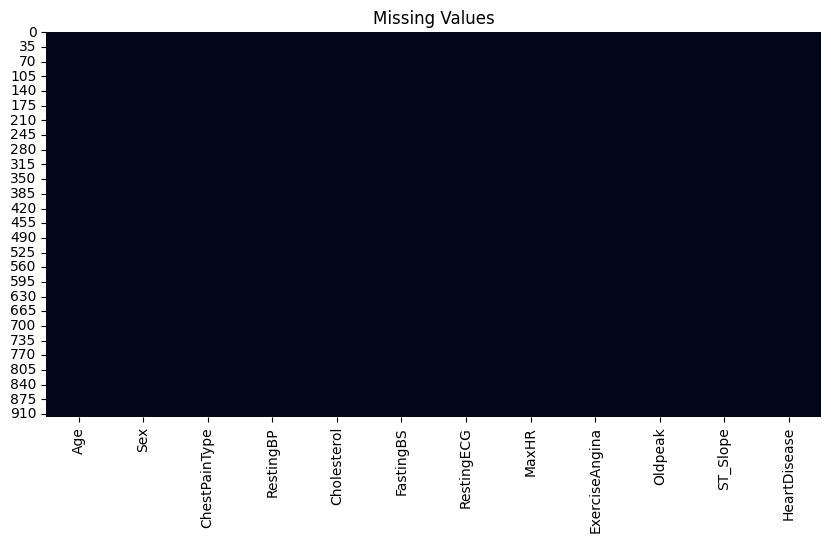

In [5]:
print(df.isnull().sum())

plt.figure(figsize=(10,5))

sns.heatmap(
    df.isnull(),
    cbar=False
)

plt.title("Missing Values")

plt.show()

In [6]:
duplicates = df.duplicated().sum()

print("Duplicates =", duplicates)

df = df.drop_duplicates()

print("Shape After Removing Duplicates")

print(df.shape)

Duplicates = 0
Shape After Removing Duplicates
(918, 12)


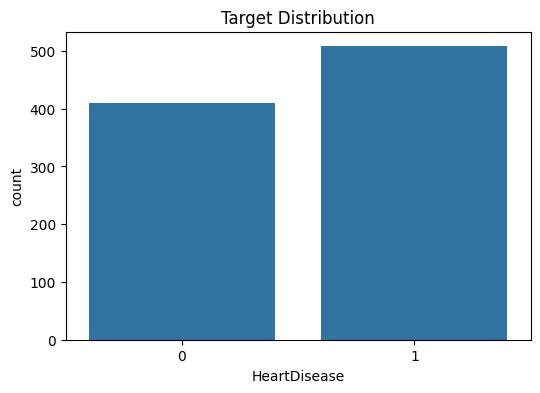

HeartDisease
1    508
0    410
Name: count, dtype: int64


In [7]:
plt.figure(figsize=(6,4))

sns.countplot(
    x='HeartDisease',
    data=df
)

plt.title("Target Distribution")

plt.show()

print(df['HeartDisease'].value_counts())

In [8]:
num_cols = df.select_dtypes(
    include=['int64','float64']
).columns.tolist()

num_cols.remove('HeartDisease')

print(num_cols)

['Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'Oldpeak']


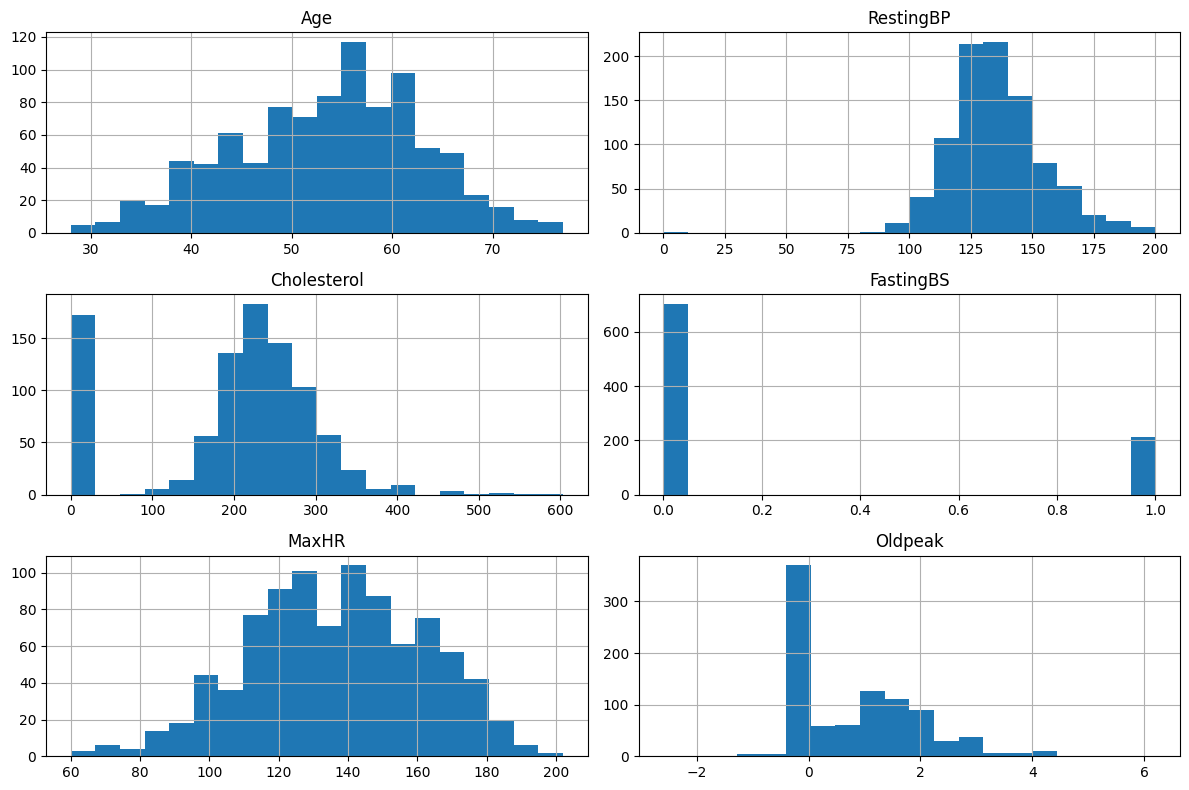

In [9]:
df[num_cols].hist(
    figsize=(12,8),
    bins=20
)

plt.tight_layout()

plt.show()

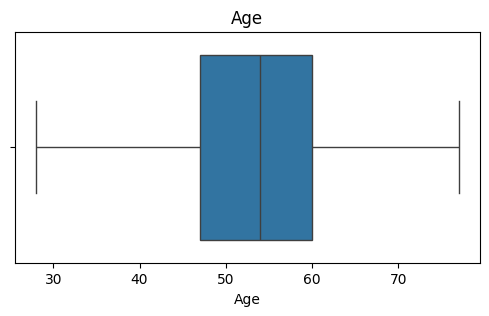

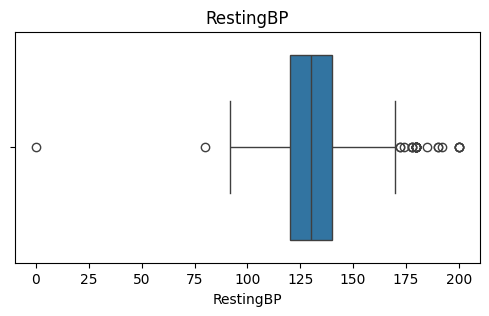

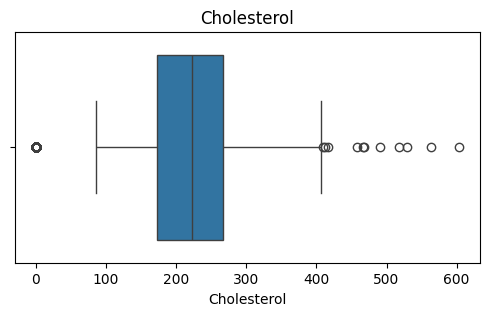

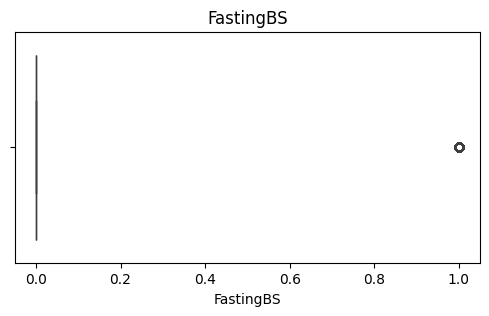

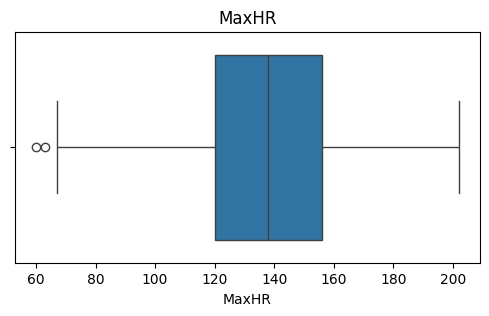

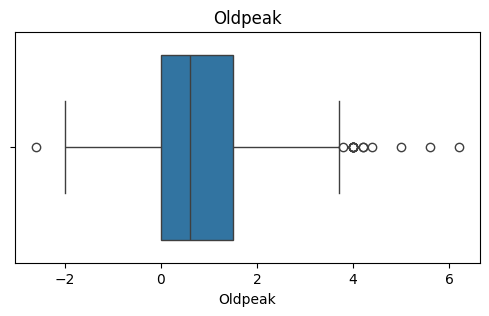

In [10]:
for col in num_cols:

    plt.figure(figsize=(6,3))

    sns.boxplot(
        x=df[col]
    )

    plt.title(col)

    plt.show()

In [11]:
cat_cols = df.select_dtypes(
    include=['object']
).columns.tolist()

print(cat_cols)

['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope']


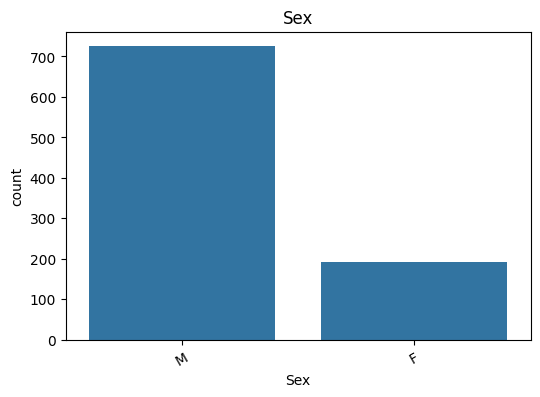

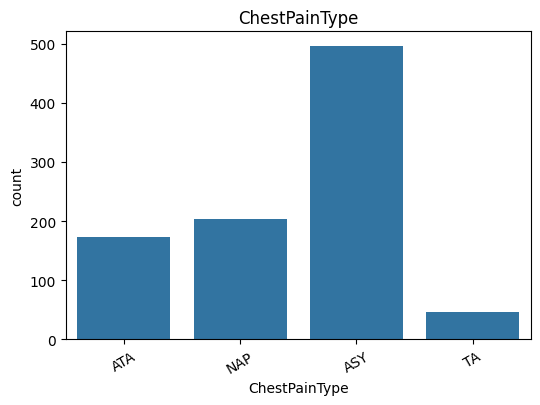

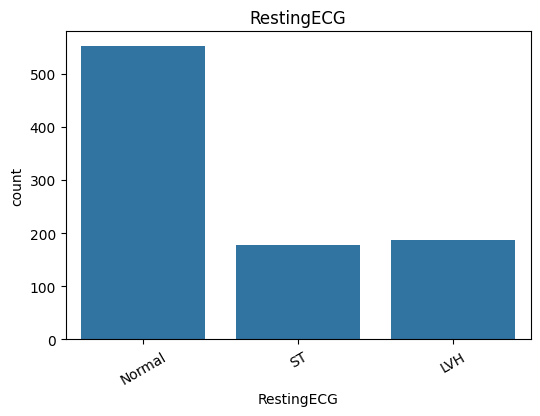

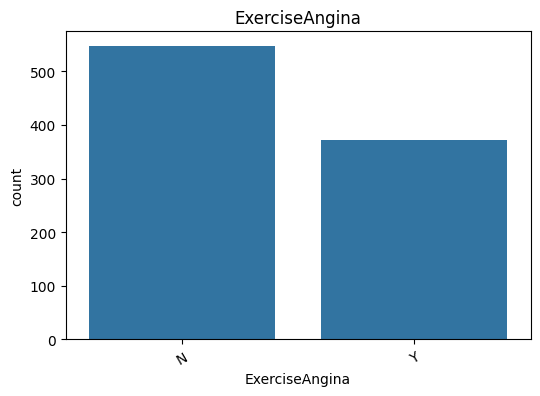

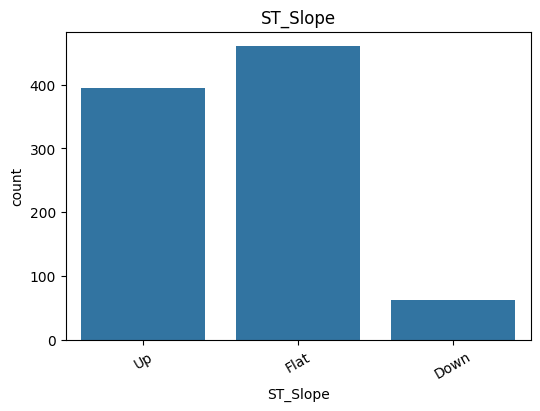

In [12]:
for col in cat_cols:

    plt.figure(figsize=(6,4))

    sns.countplot(
        x=col,
        data=df
    )

    plt.title(col)

    plt.xticks(rotation=30)

    plt.show()

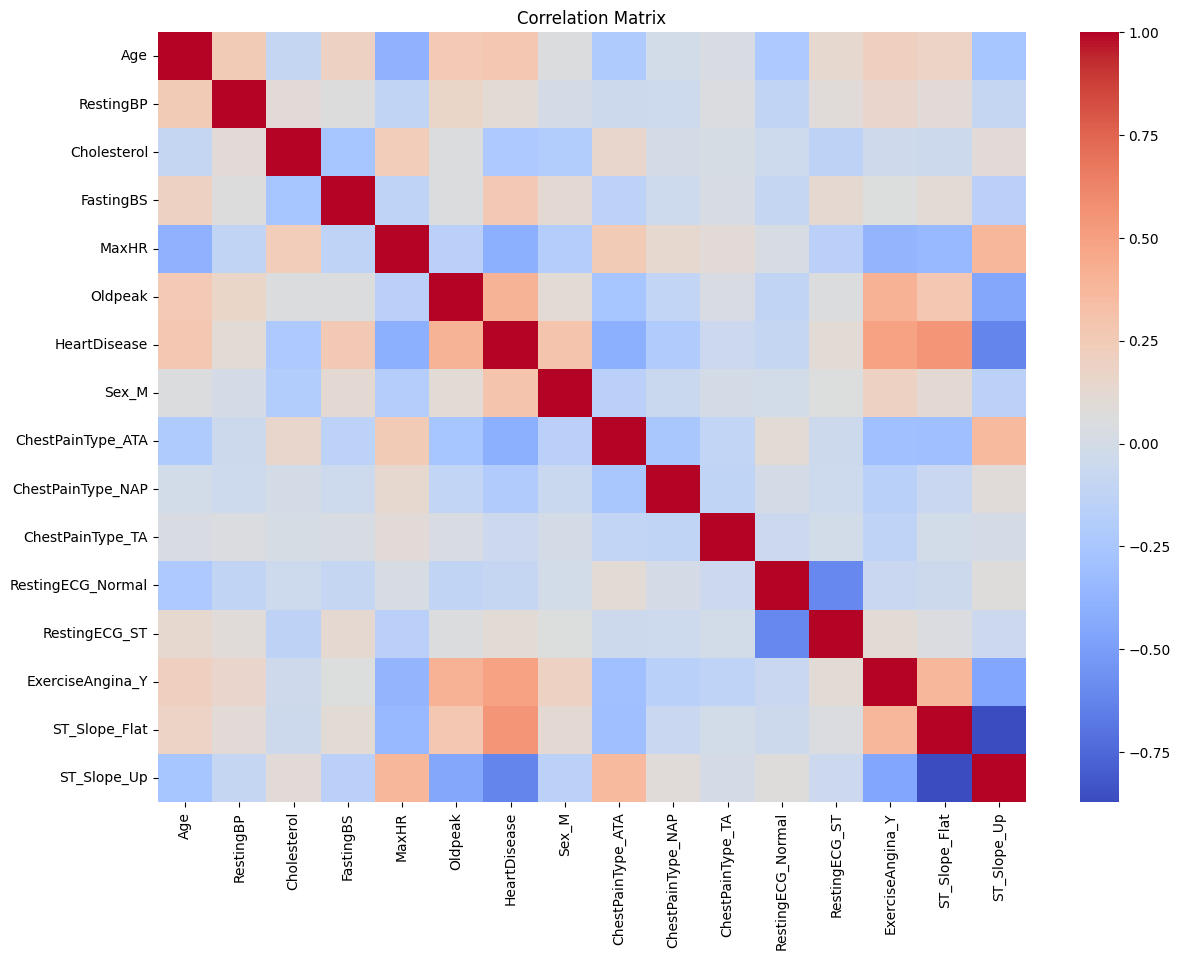

In [13]:
temp_df = pd.get_dummies(
    df,
    drop_first=True
)

plt.figure(figsize=(14,10))

sns.heatmap(
    temp_df.corr(),
    cmap='coolwarm'
)

plt.title("Correlation Matrix")

plt.show()

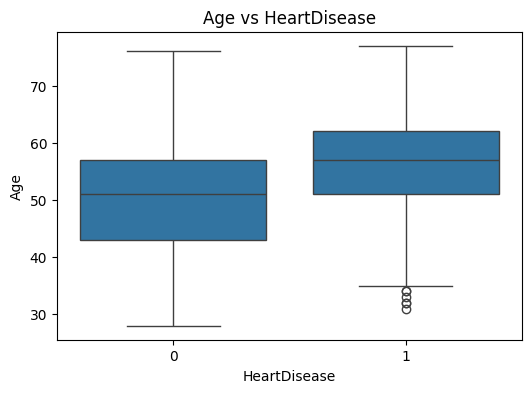

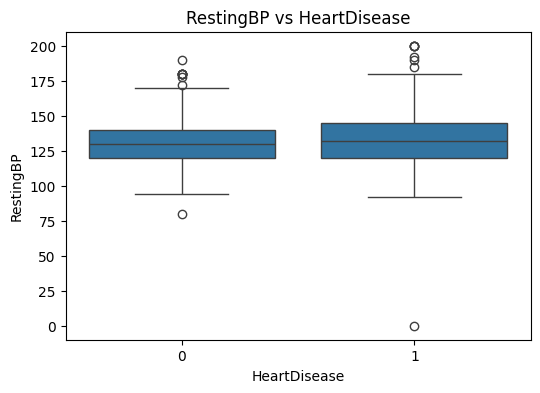

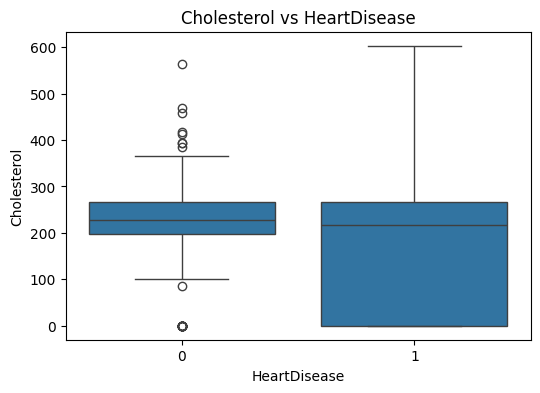

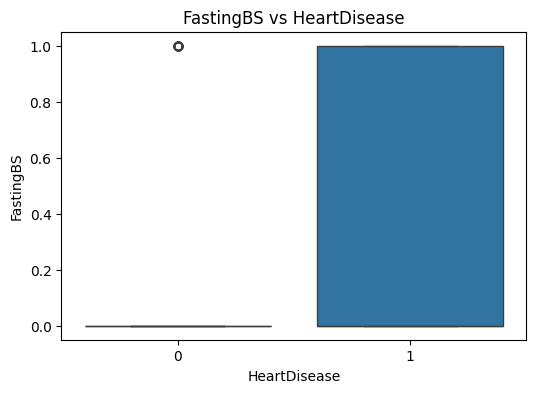

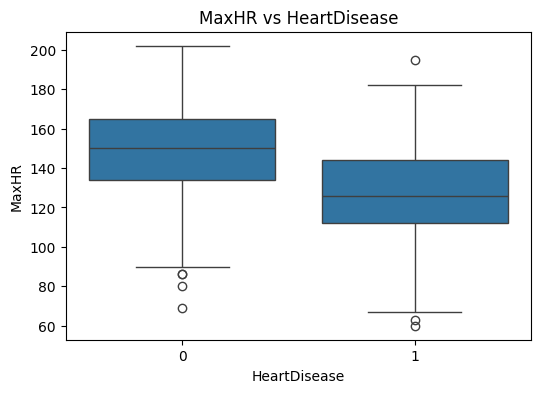

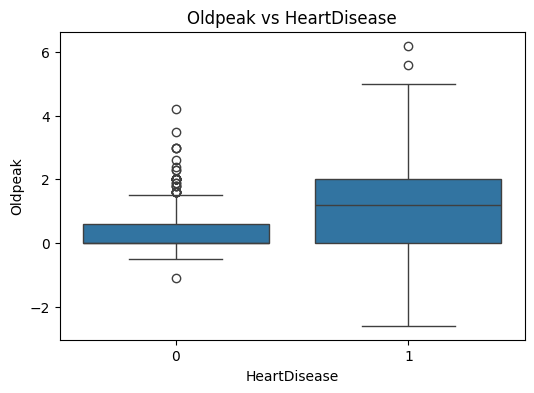

In [14]:
for col in num_cols:

    plt.figure(figsize=(6,4))

    sns.boxplot(
        x='HeartDisease',
        y=col,
        data=df
    )

    plt.title(f"{col} vs HeartDisease")

    plt.show()

In [15]:
X = df.drop(
    'HeartDisease',
    axis=1
)

y = df['HeartDisease']

In [16]:
num_cols = X.select_dtypes(
    include=['int64','float64']
).columns

cat_cols = X.select_dtypes(
    include=['object']
).columns

In [17]:
X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,

    test_size=0.20,

    stratify=y,

    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(734, 11)
(184, 11)


In [18]:
numeric_transformer = Pipeline([

    (
        'imputer',
        SimpleImputer(
            strategy='median'
        )
    ),

    (
        'scaler',
        StandardScaler()
    )
])

categorical_transformer = Pipeline([

    (
        'imputer',
        SimpleImputer(
            strategy='most_frequent'
        )
    ),

    (
        'encoder',
        OneHotEncoder(
            handle_unknown='ignore'
        )
    )
])

preprocessor = ColumnTransformer([

    (
        'num',
        numeric_transformer,
        num_cols
    ),

    (
        'cat',
        categorical_transformer,
        cat_cols
    )
])

In [19]:
X_train_processed = preprocessor.fit_transform(
    X_train
)

X_test_processed = preprocessor.transform(
    X_test
)

print(X_train_processed.shape)
print(X_test_processed.shape)

(734, 20)
(184, 20)


In [20]:
X_train_final, X_val, y_train_final, y_val = train_test_split(

    X_train_processed,
    y_train,

    test_size=0.20,

    stratify=y_train,

    random_state=42
)

print(X_train_final.shape)
print(X_val.shape)

(587, 20)
(147, 20)


In [21]:
X_train_processed = preprocessor.fit_transform(
    X_train
)

X_test_processed = preprocessor.transform(
    X_test
)

print(X_train_processed.shape)
print(X_test_processed.shape)

(734, 20)
(184, 20)


In [23]:
X_train_final, X_val, y_train_final, y_val = train_test_split(

    X_train_processed,
    y_train,

    test_size=0.20,

    stratify=y_train,

    random_state=42
)

print(X_train_final.shape)
print(X_val.shape)

(587, 20)
(147, 20)


In [24]:
X_train_tensor = torch.tensor(
    X_train_final,
    dtype=torch.float32
)

X_val_tensor = torch.tensor(
    X_val,
    dtype=torch.float32
)

X_test_tensor = torch.tensor(
    X_test_processed,
    dtype=torch.float32
)

y_train_tensor = torch.tensor(
    y_train_final.values,
    dtype=torch.float32
).reshape(-1,1)

y_val_tensor = torch.tensor(
    y_val.values,
    dtype=torch.float32
).reshape(-1,1)

y_test_tensor = torch.tensor(
    y_test.values,
    dtype=torch.float32
).reshape(-1,1)

In [25]:
train_dataset = TensorDataset(
    X_train_tensor,
    y_train_tensor
)

val_dataset = TensorDataset(
    X_val_tensor,
    y_val_tensor
)

test_dataset = TensorDataset(
    X_test_tensor,
    y_test_tensor
)

In [26]:
class ShallowNN(nn.Module):

    def __init__(self,input_dim,hidden_dim,activation):

        super().__init__()

        if activation == "relu":
            act = nn.ReLU()

        else:
            act = nn.Sigmoid()

        self.network = nn.Sequential(

            nn.Linear(input_dim,hidden_dim),

            act,

            nn.Linear(hidden_dim,1),

            nn.Sigmoid()
        )

    def forward(self,x):

        return self.network(x)

In [27]:
class DeepNN(nn.Module):

    def __init__(self,input_dim):

        super().__init__()

        self.network = nn.Sequential(

            nn.Linear(input_dim,128),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(128,64),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(64,32),
            nn.ReLU(),

            nn.Linear(32,1),

            nn.Sigmoid()
        )

    def forward(self,x):

        return self.network(x)

In [29]:
def train_model(
        model,
        train_loader,
        val_loader,
        criterion,
        optimizer,
        epochs=100
):

    history = {

        "train_loss":[],
        "val_loss":[],

        "train_acc":[],
        "val_acc":[]
    }

    for epoch in range(epochs):

        model.train()

        running_loss = 0
        correct = 0
        total = 0

        for X_batch,y_batch in train_loader:

            optimizer.zero_grad()

            outputs = model(X_batch)

            loss = criterion(
                outputs,
                y_batch
            )

            loss.backward()

            optimizer.step()

            running_loss += loss.item()

            preds = (
                outputs > 0.5
            ).float()

            correct += (
                preds == y_batch
            ).sum().item()

            total += y_batch.size(0)

        train_loss = (
            running_loss /
            len(train_loader)
        )

        train_acc = (
            correct /
            total
        )

        model.eval()

        val_loss = 0
        correct = 0
        total = 0

        with torch.no_grad():

            for X_batch,y_batch in val_loader:

                outputs = model(X_batch)

                loss = criterion(
                    outputs,
                    y_batch
                )

                val_loss += loss.item()

                preds = (
                    outputs > 0.5
                ).float()

                correct += (
                    preds == y_batch
                ).sum().item()

                total += y_batch.size(0)

        val_loss /= len(val_loader)

        val_acc = correct/total

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)

        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)

    return history

In [30]:
input_dim = X_train_tensor.shape[1]

best_acc = 0

best_shallow = None

best_params = None

for hidden in [16,32,64]:

    for activation in ["relu","sigmoid"]:

        for batch_size in [16,32,64]:

            train_loader = DataLoader(
                train_dataset,
                batch_size=batch_size,
                shuffle=True
            )

            val_loader = DataLoader(
                val_dataset,
                batch_size=batch_size
            )

            model = ShallowNN(
                input_dim,
                hidden,
                activation
            )

            criterion = nn.BCELoss()

            optimizer = optim.Adam(
                model.parameters(),
                lr=0.001
            )

            history = train_model(
                model,
                train_loader,
                val_loader,
                criterion,
                optimizer,
                epochs=50
            )

            acc = max(
                history["val_acc"]
            )

            if acc > best_acc:

                best_acc = acc

                best_shallow = model

                best_params = {
                    "hidden":hidden,
                    "activation":activation,
                    "batch_size":batch_size
                }

                shallow_history = history

print(best_params)
print(best_acc)

{'hidden': 64, 'activation': 'relu', 'batch_size': 16}
0.8707482993197279


In [31]:
best_acc = 0

best_deep = None

best_deep_params = None

for lr in [0.01,0.001,0.0001]:

    for opt_name in ["Adam","SGD"]:

        for epochs in [50,100]:

            model = DeepNN(
                input_dim
            )

            criterion = nn.BCELoss()

            if opt_name=="Adam":

                optimizer = optim.Adam(
                    model.parameters(),
                    lr=lr
                )

            else:

                optimizer = optim.SGD(
                    model.parameters(),
                    lr=lr
                )

            train_loader = DataLoader(
                train_dataset,
                batch_size=32,
                shuffle=True
            )

            val_loader = DataLoader(
                val_dataset,
                batch_size=32
            )

            history = train_model(
                model,
                train_loader,
                val_loader,
                criterion,
                optimizer,
                epochs
            )

            acc = max(
                history["val_acc"]
            )

            if acc > best_acc:

                best_acc = acc

                best_deep = model

                best_deep_params = {

                    "lr":lr,
                    "optimizer":opt_name,
                    "epochs":epochs
                }

                deep_history = history

print(best_deep_params)
print(best_acc)

{'lr': 0.01, 'optimizer': 'Adam', 'epochs': 50}
0.8775510204081632


In [32]:
def evaluate_model(model):

    model.eval()

    with torch.no_grad():

        probs = model(
            X_test_tensor
        ).numpy()

    preds = (
        probs > 0.5
    ).astype(int)

    acc = accuracy_score(
        y_test,
        preds
    )

    precision = precision_score(
        y_test,
        preds
    )

    recall = recall_score(
        y_test,
        preds
    )

    f1 = f1_score(
        y_test,
        preds
    )

    auc = roc_auc_score(
        y_test,
        probs
    )

    return {

        "accuracy":acc,
        "precision":precision,
        "recall":recall,
        "f1":f1,
        "auc":auc,

        "preds":preds,
        "probs":probs
    }

In [33]:
shallow_results = evaluate_model(
    best_shallow
)

deep_results = evaluate_model(
    best_deep
)

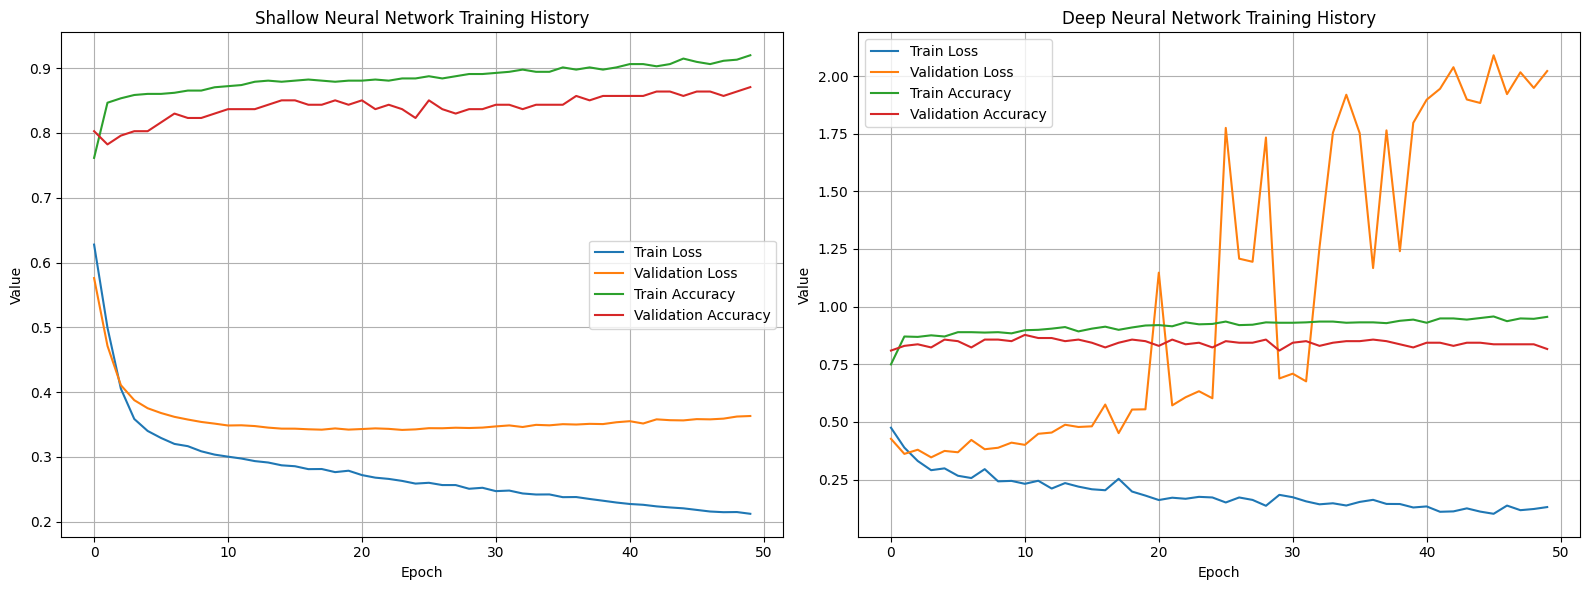

In [34]:
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# ==========================
# Shallow NN
# ==========================

ax[0].plot(
    shallow_history["train_loss"],
    label="Train Loss"
)

ax[0].plot(
    shallow_history["val_loss"],
    label="Validation Loss"
)

ax[0].plot(
    shallow_history["train_acc"],
    label="Train Accuracy"
)

ax[0].plot(
    shallow_history["val_acc"],
    label="Validation Accuracy"
)

ax[0].set_title(
    "Shallow Neural Network Training History"
)

ax[0].set_xlabel(
    "Epoch"
)

ax[0].set_ylabel(
    "Value"
)

ax[0].legend()

ax[0].grid(True)

# ==========================
# Deep NN
# ==========================

ax[1].plot(
    deep_history["train_loss"],
    label="Train Loss"
)

ax[1].plot(
    deep_history["val_loss"],
    label="Validation Loss"
)

ax[1].plot(
    deep_history["train_acc"],
    label="Train Accuracy"
)

ax[1].plot(
    deep_history["val_acc"],
    label="Validation Accuracy"
)

ax[1].set_title(
    "Deep Neural Network Training History"
)

ax[1].set_xlabel(
    "Epoch"
)

ax[1].set_ylabel(
    "Value"
)

ax[1].legend()

ax[1].grid(True)

plt.tight_layout()

plt.show()

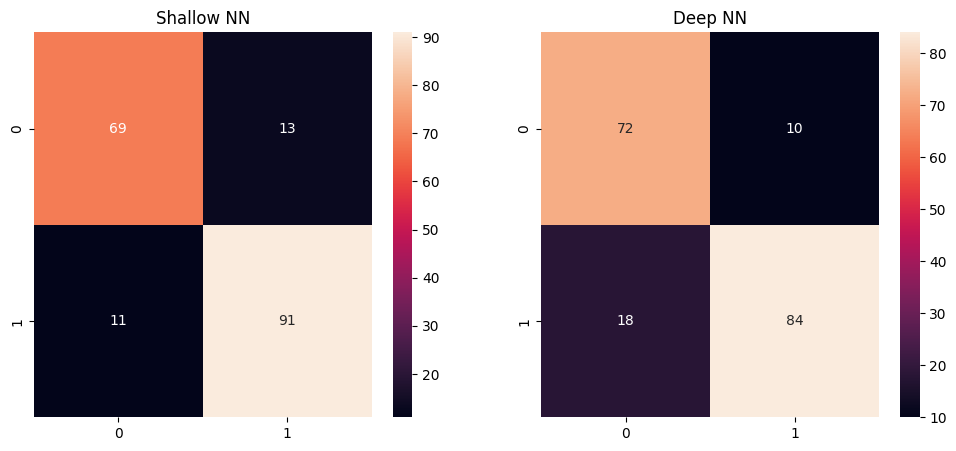

In [35]:
fig,ax = plt.subplots(
    1,2,
    figsize=(12,5)
)

cm1 = confusion_matrix(
    y_test,
    shallow_results["preds"]
)

cm2 = confusion_matrix(
    y_test,
    deep_results["preds"]
)

sns.heatmap(
    cm1,
    annot=True,
    fmt='d',
    ax=ax[0]
)

ax[0].set_title(
    "Shallow NN"
)

sns.heatmap(
    cm2,
    annot=True,
    fmt='d',
    ax=ax[1]
)

ax[1].set_title(
    "Deep NN"
)

plt.show()

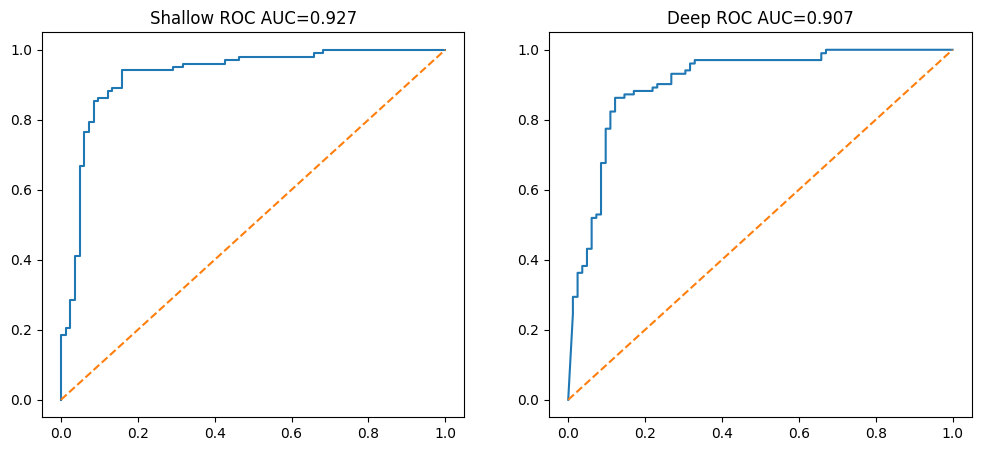

In [36]:
fig,ax = plt.subplots(
    1,2,
    figsize=(12,5)
)

fpr,tpr,_ = roc_curve(
    y_test,
    shallow_results["probs"]
)

ax[0].plot(
    fpr,
    tpr
)

ax[0].plot(
    [0,1],
    [0,1],
    '--'
)

ax[0].set_title(
    f"Shallow ROC AUC={shallow_results['auc']:.3f}"
)

fpr,tpr,_ = roc_curve(
    y_test,
    deep_results["probs"]
)

ax[1].plot(
    fpr,
    tpr
)

ax[1].plot(
    [0,1],
    [0,1],
    '--'
)

ax[1].set_title(
    f"Deep ROC AUC={deep_results['auc']:.3f}"
)

plt.show()

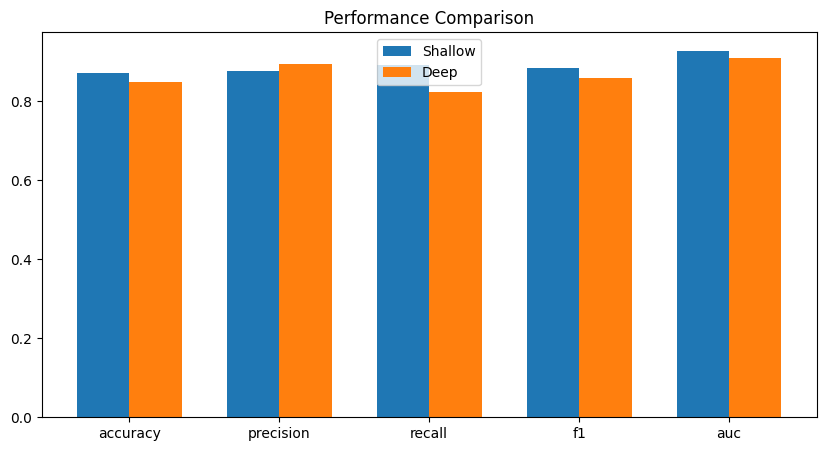

In [38]:
metrics = [
    "accuracy",
    "precision",
    "recall",
    "f1",
    "auc"
]

shallow_scores = [
    shallow_results[m]
    for m in metrics
]

deep_scores = [
    deep_results[m]
    for m in metrics
]

x = np.arange(
    len(metrics)
)

width = 0.35

plt.figure(
    figsize=(10,5)
)

plt.bar(
    x-width/2,
    shallow_scores,
    width,
    label="Shallow"
)

plt.bar(
    x+width/2,
    deep_scores,
    width,
    label="Deep"
)

plt.xticks(
    x,
    metrics
)

plt.legend()

plt.title(
    "Performance Comparison"
)

plt.show()

In [39]:
print("SHALLOW NETWORK")
print(best_shallow)

print("\n")

print("DEEP NETWORK")
print(best_deep)

SHALLOW NETWORK
ShallowNN(
  (network): Sequential(
    (0): Linear(in_features=20, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=1, bias=True)
    (3): Sigmoid()
  )
)


DEEP NETWORK
DeepNN(
  (network): Sequential(
    (0): Linear(in_features=20, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=128, out_features=64, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.3, inplace=False)
    (6): Linear(in_features=64, out_features=32, bias=True)
    (7): ReLU()
    (8): Linear(in_features=32, out_features=1, bias=True)
    (9): Sigmoid()
  )
)
